# Data Understanding and Preparation 

Covers **Stage 1 (Dataset Understanding + EDA)** and **Stage 2 (Data Preparation)**. 
- Each stage below lists its **sub-tasks as a checklist**
- Complete every `# TODO` so each checklist item is satisfied
- Implement the reusable logic in `src/data_prep.py` and call it here so the same code backs your notebook and the later stages

**File ownership** — 
- *Provided (no change needed):* `config.py` (paths, target, column lists, params)
- *Provided to extend:* `src/data_prep.py` (function stubs)
- *You create:* the cells below + the report sections

**Business context:** flag diabetic inpatients at risk of 30-day readmission so care teams can intervene. The target is highly imbalanced (~9%), so metric choice and leakage prevention matter.

# Stage 1 - Business & Data Understanding, EDA, and Methodology  <font color="red">[20 marks]</font>

> **Stage 1 also has report-only tasks** graded from the MLOps report, not this notebook: **1.1 Business Understanding** (1.1.1–1.1.3) and **1.4 Methodology Design** (1.4.1–1.4.2).

In [11]:
# tgus will capture the logs and store it in file 
from pathlib import Path
from datetime import datetime

OUTPUT_LOG = Path("artifacts/capstone_outputs.txt")
OUTPUT_LOG.parent.mkdir(parents=True, exist_ok=True)

def log_output(title, content):
    with open(OUTPUT_LOG, "a", encoding="utf-8") as f:
        f.write("\n" + "=" * 80 + "\n")
        f.write(f"{title}\n")
        f.write(f"Generated: {datetime.now()}\n")
        f.write("=" * 80 + "\n")

        if isinstance(content, pd.DataFrame):
            f.write(content.to_string())
        elif isinstance(content, pd.Series):
            f.write(content.to_string())
        else:
            f.write(str(content))

        f.write("\n")
        
OUTPUT_LOG.write_text("", encoding="utf-8")

0

In [12]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import config as cfg
# TODO: load data/diabetic_data.csv treating '?' as NaN (na_values=['?']); print shape; head(3).

raw = pd.read_csv(cfg.RAW_CSV, na_values=['?'])

print("Dataset shape:", raw.shape)

raw.head(3)

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## Stage 1.2 — Dataset Understanding <font color="red">[4 marks]</font>

- **1.2.1 — Dataset structure, target derivation & patients-vs-encounters [2]** — print the shape (~101,766 × 50), derive the target (`readmitted` `<30` → 1), and compare unique patients (`patient_nbr`) vs encounters.
- **1.2.2 — Feature types & data-quality / missing-value quantification [2]** — summarise feature types and build a per-column missing-value table with percentages (note `?` was loaded as NaN; e.g. `weight` ~97% missing).

In [13]:
# TODO 1.2.1: print rows/columns; compare unique patients vs encounters; derive the binary target.

# 1.2.1 — Dataset structure, target derivation & patients-vs-encounters

print("Rows:", raw.shape[0])
print("Columns:", raw.shape[1])

print("Total encounters:", len(raw))
print("Unique patients:", raw["patient_nbr"].nunique())

# Create a copy for Stage 1 analysis so the raw dataframe remains unchanged
eda = raw.copy()

# Binary target: readmitted within 30 days = 1, otherwise = 0
eda[cfg.TARGET] = (eda["readmitted"] == "<30").astype(int)

print("\nRaw target distribution:")
print(eda[cfg.TARGET].value_counts())

print("\nRaw positive rate:")
print(f"{eda[cfg.TARGET].mean() * 100:.2f}%")

#TODO 1.2.2: print feature dtypes summary and a missing-value table (count + pct) per column.

# 1.2.2 — Feature types and missing-value quantification

print("\nFeature type summary:")
print(raw.dtypes.value_counts())

missing_table = pd.DataFrame({
    "missing_count": raw.isna().sum(),
    "missing_pct": (raw.isna().mean() * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print("\nMissing-value summary:")
display(missing_table)

Rows: 101766
Columns: 50
Total encounters: 101766
Unique patients: 71518

Raw target distribution:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

Raw positive rate:
11.16%

Feature type summary:
object    37
int64     13
Name: count, dtype: int64

Missing-value summary:


,missing_count,missing_pct
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02
patient_nbr,0,0.00


## Stage 1.3 — Exploratory Data Analysis <font color="red">[7 marks]</font>

- **1.3.1 — Univariate analysis [3]** — visualise the target imbalance and ≥3 numeric feature distributions, with brief observations.
- **1.3.2 — Bivariate analysis vs target [2]** — analyse ≥1 relationship to the target (e.g. readmission rate vs prior inpatient visits) and interpret it.
- **1.3.3 — Visualisations + written interpretation [2]** — clear, labelled plots; interpret each key finding in writing (see the interpretation cell below).

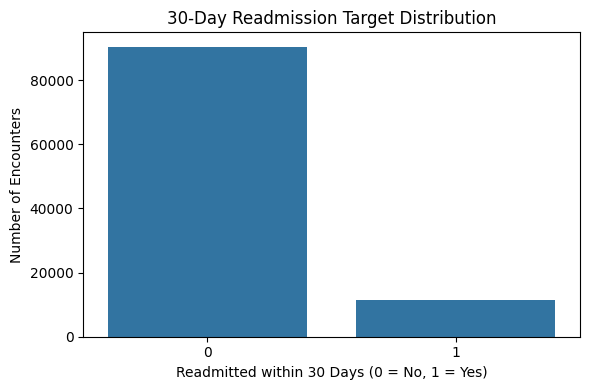

Target Distribution:


,count,percentage
readmitted_30d,,
0,90409,88.84
1,11357,11.16


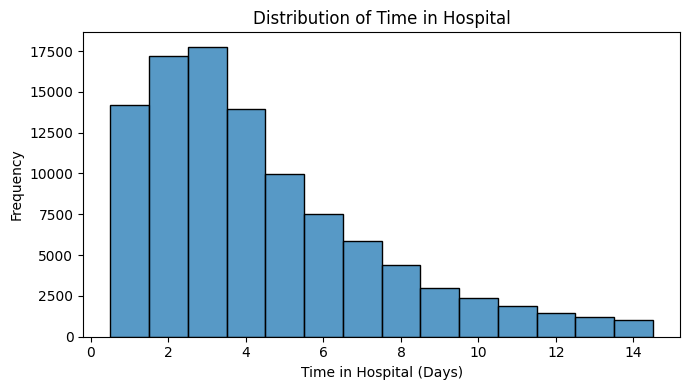

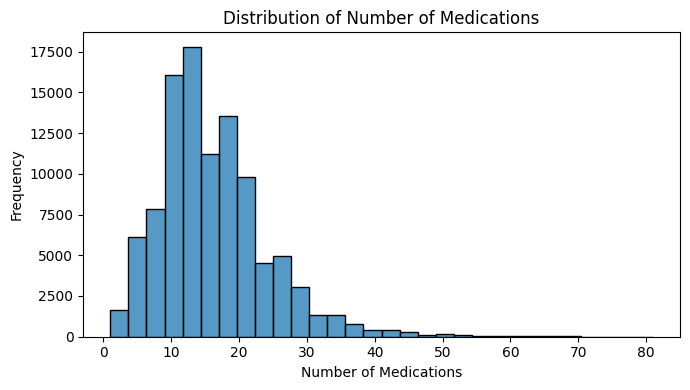

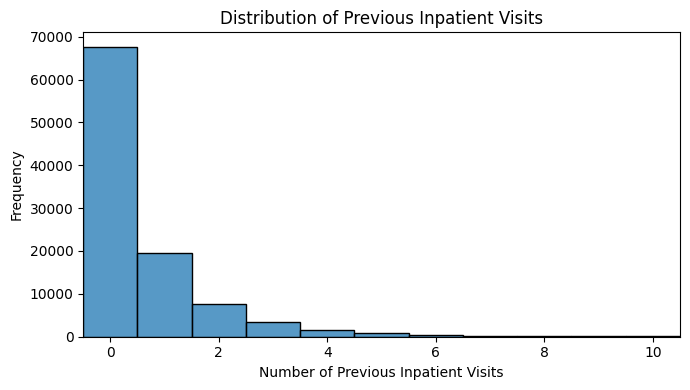

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


30-Day Readmission by Previous Inpatient Visits:


,inpatient_visit_group,encounter_count,readmission_rate_pct
0,0,67630,8.44
1,1,19521,12.92
2,2,7566,17.43
3,3+,7049,25.66


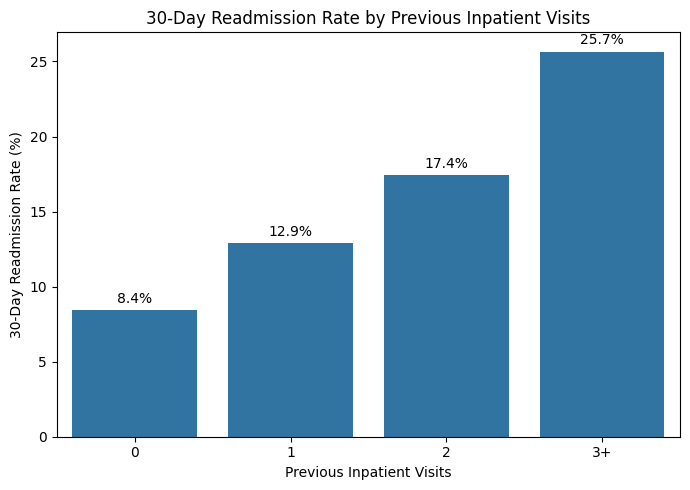

In [14]:
# TODO 1.3.1: plot the target imbalance + >=3 numeric distributions.
plt.figure(figsize=(6, 4))

sns.countplot(
    data=eda,
    x=cfg.TARGET
)

plt.title("30-Day Readmission Target Distribution")
plt.xlabel("Readmitted within 30 Days (0 = No, 1 = Yes)")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()


# Target distribution table
target_summary = pd.DataFrame({
    "count": eda[cfg.TARGET].value_counts().sort_index(),
    "percentage": (
        eda[cfg.TARGET]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

print("Target Distribution:")
display(target_summary)


plt.figure(figsize=(7, 4))

sns.histplot(
    data=eda,
    x="time_in_hospital",
    discrete=True
)

plt.title("Distribution of Time in Hospital")
plt.xlabel("Time in Hospital (Days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))

sns.histplot(
    data=eda,
    x="num_medications",
    bins=30
)

plt.title("Distribution of Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



plt.figure(figsize=(7, 4))

sns.histplot(
    data=eda,
    x="number_inpatient",
    discrete=True
)

plt.title("Distribution of Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Frequency")

# Restrict visual range because most observations occur
# between 0 and 10 previous inpatient visits.
plt.xlim(-0.5, 10.5)

plt.tight_layout()
plt.show()


# Summary statistics for selected numerical features
numeric_eda_cols = [
    "time_in_hospital",
    "num_medications",
    "number_inpatient"
]

print("Summary Statistics:")
display(eda[numeric_eda_cols].describe().T)


# TODO 1.3.2: plot >=1 bivariate view vs the target (e.g. readmit rate by prior inpatient visits).
# TODO 1.3.3: ensure plots are labelled; record findings in the interpretation cell.

# Group previous inpatient visits into interpretable categories
eda["inpatient_visit_group"] = pd.cut(
    eda["number_inpatient"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)


# Calculate readmission rate for each utilisation group
inpatient_analysis = (
    eda.groupby(
        "inpatient_visit_group",
        observed=True
    )[cfg.TARGET]
    .agg(
        encounter_count="count",
        readmission_rate="mean"
    )
    .reset_index()
)


# Convert readmission rate to percentage
inpatient_analysis["readmission_rate_pct"] = (
    inpatient_analysis["readmission_rate"] * 100
).round(2)


print("30-Day Readmission by Previous Inpatient Visits:")

display(
    inpatient_analysis[
        [
            "inpatient_visit_group",
            "encounter_count",
            "readmission_rate_pct"
        ]
    ]
)


plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=inpatient_analysis,
    x="inpatient_visit_group",
    y="readmission_rate_pct"
)

plt.title(
    "30-Day Readmission Rate by Previous Inpatient Visits"
)

plt.xlabel("Previous Inpatient Visits")
plt.ylabel("30-Day Readmission Rate (%)")


# Display percentages above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### ✍️ Interpretation (1.3.3)
*TODO: what does the ~9% imbalance imply for metric choice? Which columns are unusable (e.g. weight ~97% missing) and why? What does the bivariate view tell you?*

### ✍️ Interpretation (1.3.3)

The target variable is highly imbalanced, with only a small proportion of encounters representing 30-day readmissions. Therefore, accuracy alone would be misleading because a model predicting mostly the majority class could still obtain high accuracy. Model evaluation should instead emphasise imbalance-aware measures such as ROC-AUC, PR-AUC, recall, precision and F1-score, with particular attention to recall because missed high-risk patients represent clinically important false negatives.

The missing-value analysis also shows that some variables are unsuitable for modelling. In particular, `weight` is approximately 96.86% missing and therefore provides too little reliable information to justify retention. Other variables with substantial missingness require appropriate treatment rather than naïve deletion. 

The bivariate analysis shows a clear relationship between prior inpatient utilisation and 30-day readmission risk. The readmission rate increases from approximately 8.44% for patients with no prior inpatient visits to 12.92% for one visit, 17.43% for two visits and 25.66% for three or more visits. This indicates that previous inpatient utilisation is an important risk indicator and supports its inclusion in the predictive model.

### Stage 1.3 — EDA Observations and Interpretation

**Target Distribution**

The 30-day readmission target is highly imbalanced. Only about 11% of the raw encounter-level observations belong to the positive readmission class, while the majority are not readmitted within 30 days. Therefore, accuracy alone would not be an appropriate metric for model evaluation, since a model predicting the majority class could achieve high accuracy while failing to identify high-risk patients.

**Time in Hospital**

Most hospital encounters involve relatively short stays. The number of observations generally decreases as the duration of hospitalisation increases, indicating a right-skewed distribution. Longer hospital stays represent a comparatively smaller proportion of encounters.

**Number of Medications**

The number of medications is also right-skewed. Most patients receive a moderate number of medications, while a smaller proportion receive substantially larger numbers. Higher medication counts may reflect greater clinical complexity and could potentially contribute useful predictive information.

**Previous Inpatient Visits**

Most encounters have no previous inpatient admissions. The frequency decreases sharply as the number of previous admissions increases, resulting in a strongly right-skewed distribution. This indicates that repeated inpatient utilisation occurs in a comparatively small subset of patients.

**Previous Inpatient Visits vs 30-Day Readmission**

A clear positive relationship is observed between previous inpatient utilisation and 30-day readmission. Patients with no previous inpatient admissions have the lowest readmission rate, while the readmission rate increases progressively for patients with one, two, and three or more previous inpatient visits.

This suggests that prior inpatient utilisation is an important indicator of future readmission risk. Patients with repeated admissions may represent a clinically more complex or higher-risk population and could therefore benefit from additional discharge planning and post-discharge follow-up.

## Stage 2 — Data Preparation  <font color="red">[25 marks]</font>

## Stage 2.1 — Data Cleaning <font color="red">[6 marks]</font>

Implement `clean()` in `src/data_prep.py`, then call it here.

- **2.1.1 — Missing value handling & invalid value treatment [2]** — `?`→NaN; drop `weight` and constant/zero-variance medication columns.
- **2.1.2 — Patient deduplication & removal of invalid records [2]** — keep the FIRST encounter per patient (`drop_duplicates('patient_nbr')`, prevents leakage); drop expired/hospice discharges (`discharge_disposition_id` ∈ {11,13,14,19,20,21}).
- **2.1.3 — Target variable creation & validation [2]** — build the binary target and validate its class balance (expect ~69,973 rows, ~9% positive).

In [15]:
# TODO (src/data_prep.py clean()): implement sub-tasks 2.1.1–2.1.3 above.
# TODO (here): clean = dp.clean(raw); print the resulting shape and target rate.

# Import reusable preprocessing functions from src folder
from src import data_prep as dp

# Reload module so notebook picks up the latest changes
import importlib
importlib.reload(dp)


# Apply Stage 2.1 cleaning
clean = dp.clean(raw)

print("Cleaned dataset shape:")
print(clean.shape)


print("\nTarget distribution:")
print(clean[cfg.TARGET].value_counts())


print("\nTarget distribution (%):")
print(
    clean[cfg.TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print(
    f"\n30-day readmission rate: "
    f"{clean[cfg.TARGET].mean() * 100:.2f}%"
)


# Check whether identifier / unusable columns were removed
print("\nDropped columns still present:")
print(
    [
        col for col in cfg.DROP_COLS
        if col in clean.columns
    ]
)


# Ensure original outcome column was removed
print(
    "\nOriginal 'readmitted' column present:",
    "readmitted" in clean.columns
)


#2.1.2 
# LOGGING 
log_output(
    "STAGE 2.1 - DATA CLEANING",
    f"""
Cleaned dataset shape: {clean.shape}

Target Counts:
{clean[cfg.TARGET].value_counts().to_string()}

Target Distribution (%):
{(clean[cfg.TARGET].value_counts(normalize=True) * 100).round(2).to_string()}

30-Day Readmission Rate: {clean[cfg.TARGET].mean() * 100:.2f}%

Original readmitted column present: {"readmitted" in clean.columns}
"""
)

Cleaned dataset shape:
(69973, 38)

Target distribution:
readmitted_30d
0    63696
1     6277
Name: count, dtype: int64

Target distribution (%):
readmitted_30d
0    91.03
1     8.97
Name: proportion, dtype: float64

30-day readmission rate: 8.97%

Dropped columns still present:
[]

Original 'readmitted' column present: False


## Stage 2.2 — Feature Engineering <font color="red">[8 marks]</font>

Implement `engineer_features()` in `src/data_prep.py`.

- **2.2.1 — ICD-9 diagnosis grouping into clinical categories [4]** — group `diag_1/2/3` into clinical categories (circulatory, respiratory, diabetes, injury, other) with a justified mapping.
- **2.2.2 — Additional engineered features, justified [4]** — ≥3 of {age midpoint, service_utilization, num_med_changes, medical_specialty top-k grouping}, each justified.

In [16]:
# TODO (src/data_prep.py engineer_features()): implement sub-tasks 2.2.1–2.2.2 above.
# TODO (here): fe = dp.engineer_features(clean); preview the new feature columns.


# Stage 2.2 — Feature Engineering


# Reload the reusable preprocessing module
import importlib
importlib.reload(dp)


# Apply feature engineering
fe = dp.engineer_features(clean)


print("Feature-engineered dataset shape:")
print(fe.shape)



# Preview engineered features


engineered_cols = [
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "service_utilization",
    "num_med_changes",
    "medical_specialty"
]

display(
    fe[engineered_cols].head(10)
)



# Validate ICD-9 grouping


print("\nPrimary diagnosis categories:")
print(
    fe["diag_1"]
    .value_counts(dropna=False)
)



# Stage 2.2 — Feature Engineering


# Reload the reusable preprocessing module
import importlib
importlib.reload(dp)


# Apply feature engineering
fe = dp.engineer_features(clean)


print("Feature-engineered dataset shape:")
print(fe.shape)



# Preview engineered features


engineered_cols = [
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "service_utilization",
    "num_med_changes",
    "medical_specialty"
]

display(
    fe[engineered_cols].head(10)
)



# Validate ICD-9 grouping


print("\nPrimary diagnosis categories:")
print(
    fe["diag_1"]
    .value_counts(dropna=False)
)



# Validate age transformation


print("\nAge summary after midpoint conversion:")
print(
    fe["age"].describe()
)



# Validate service utilisation


print("\nService utilisation summary:")
print(
    fe["service_utilization"].describe()
)



# Stage 2.2 — Feature Engineering


# Reload the reusable preprocessing module
import importlib
importlib.reload(dp)


# Apply feature engineering
fe = dp.engineer_features(clean)


print("Feature-engineered dataset shape:")
print(fe.shape)



# Preview engineered features


engineered_cols = [
    "age",
    "diag_1",
    "diag_2",
    "diag_3",
    "service_utilization",
    "num_med_changes",
    "medical_specialty"
]

display(
    fe[engineered_cols].head(10)
)



# Validate ICD-9 grouping


print("\nPrimary diagnosis categories:")
print(
    fe["diag_1"]
    .value_counts(dropna=False)
)



# Validate age transformation


print("\nAge summary after midpoint conversion:")
print(
    fe["age"].describe()
)



# Validate service utilisation


print("\nService utilisation summary:")
print(
    fe["service_utilization"].describe()
)



# Validate medication-change feature


print("\nMedication change count distribution:")
print(
    fe["num_med_changes"]
    .value_counts()
    .sort_index()
)



# Validate specialty grouping


print("\nMedical specialty categories:")
print(
    fe["medical_specialty"]
    .value_counts(dropna=False))

# Validate medication-change feature


print("\nMedication change count distribution:")
print(
    fe["num_med_changes"]
    .value_counts()
    .sort_index()
)



# Validate specialty grouping


print("\nMedical specialty categories:")
print(
    fe["medical_specialty"]
    .value_counts(dropna=False)
)
# Validate age transformation


print("\nAge summary after midpoint conversion:")
print(
    fe["age"].describe()
)



# Validate service utilisation


print("\nService utilisation summary:")
print(
    fe["service_utilization"].describe()
)



# Validate medication-change feature


print("\nMedication change count distribution:")
print(
    fe["num_med_changes"]
    .value_counts()
    .sort_index()
)



# Validate specialty grouping
print("\nMedical specialty categories:")
print(
    fe["medical_specialty"]
    .value_counts(dropna=False)
)

# LOGGING 

log_output(
    "STAGE 2.2 - FEATURE ENGINEERING",
    f"""
Dataset shape: {fe.shape}

Primary Diagnosis Categories:
{fe["diag_1"].value_counts(dropna=False).to_string()}

Age Summary:
{fe["age"].describe().to_string()}

Service Utilization Summary:
{fe["service_utilization"].describe().to_string()}

Medication Change Distribution:
{fe["num_med_changes"].value_counts().sort_index().to_string()}

Medical Specialty Categories:
{fe["medical_specialty"].value_counts(dropna=False).to_string()}
"""
)

Feature-engineered dataset shape:
(69973, 40)


,age,diag_1,diag_2,diag_3,service_utilization,num_med_changes,medical_specialty
0,85.0,Circulatory,Circulatory,Other,0,0,Missing
1,95.0,Circulatory,Other,Respiratory,0,0,InternalMedicine
2,45.0,Other,Other,Diabetes,0,0,Missing
3,45.0,Diabetes,Circulatory,Injury,0,0,Missing
4,55.0,Circulatory,Circulatory,Diabetes,0,0,Missing
5,65.0,Other,Other,Other,0,1,Missing
6,45.0,Circulatory,Diabetes,Diabetes,1,2,Family/GeneralPractice
7,85.0,Circulatory,Circulatory,Circulatory,0,0,Family/GeneralPractice
8,65.0,Circulatory,Circulatory,Other,0,0,Missing
9,65.0,Respiratory,Injury,Other,0,0,Missing



Primary diagnosis categories:
diag_1
Other          28651
Circulatory    21384
Respiratory     9486
Diabetes        5748
Injury          4694
Missing           10
Name: count, dtype: int64
Feature-engineered dataset shape:
(69973, 40)


,age,diag_1,diag_2,diag_3,service_utilization,num_med_changes,medical_specialty
0,85.0,Circulatory,Circulatory,Other,0,0,Missing
1,95.0,Circulatory,Other,Respiratory,0,0,InternalMedicine
2,45.0,Other,Other,Diabetes,0,0,Missing
3,45.0,Diabetes,Circulatory,Injury,0,0,Missing
4,55.0,Circulatory,Circulatory,Diabetes,0,0,Missing
5,65.0,Other,Other,Other,0,1,Missing
6,45.0,Circulatory,Diabetes,Diabetes,1,2,Family/GeneralPractice
7,85.0,Circulatory,Circulatory,Circulatory,0,0,Family/GeneralPractice
8,65.0,Circulatory,Circulatory,Other,0,0,Missing
9,65.0,Respiratory,Injury,Other,0,0,Missing



Primary diagnosis categories:
diag_1
Other          28651
Circulatory    21384
Respiratory     9486
Diabetes        5748
Injury          4694
Missing           10
Name: count, dtype: int64

Age summary after midpoint conversion:
count    69973.000000
mean        65.440313
std         15.973942
min          5.000000
25%         55.000000
50%         65.000000
75%         75.000000
max         95.000000
Name: age, dtype: float64

Service utilisation summary:
count    69973.000000
mean         0.559702
std          1.427760
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         49.000000
Name: service_utilization, dtype: float64
Feature-engineered dataset shape:
(69973, 40)


,age,diag_1,diag_2,diag_3,service_utilization,num_med_changes,medical_specialty
0,85.0,Circulatory,Circulatory,Other,0,0,Missing
1,95.0,Circulatory,Other,Respiratory,0,0,InternalMedicine
2,45.0,Other,Other,Diabetes,0,0,Missing
3,45.0,Diabetes,Circulatory,Injury,0,0,Missing
4,55.0,Circulatory,Circulatory,Diabetes,0,0,Missing
5,65.0,Other,Other,Other,0,1,Missing
6,45.0,Circulatory,Diabetes,Diabetes,1,2,Family/GeneralPractice
7,85.0,Circulatory,Circulatory,Circulatory,0,0,Family/GeneralPractice
8,65.0,Circulatory,Circulatory,Other,0,0,Missing
9,65.0,Respiratory,Injury,Other,0,0,Missing



Primary diagnosis categories:
diag_1
Other          28651
Circulatory    21384
Respiratory     9486
Diabetes        5748
Injury          4694
Missing           10
Name: count, dtype: int64

Age summary after midpoint conversion:
count    69973.000000
mean        65.440313
std         15.973942
min          5.000000
25%         55.000000
50%         65.000000
75%         75.000000
max         95.000000
Name: age, dtype: float64

Service utilisation summary:
count    69973.000000
mean         0.559702
std          1.427760
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         49.000000
Name: service_utilization, dtype: float64

Medication change count distribution:
num_med_changes
0    52725
1    16252
2      919
3       74
4        3
Name: count, dtype: int64

Medical specialty categories:
medical_specialty
Missing                       33639
InternalMedicine              10641
Other                          5486
Family/GeneralPractice     

## Stage 2.3 — Feature Transformation <font color="red">[5 marks]</font>

Implement `build_preprocessor()` in `src/data_prep.py`.

- **2.3.1 — Numeric scaling & categorical encoding [3]** — numeric: median-impute + scale; categorical: impute + `OneHotEncoder(handle_unknown='ignore')`.
- **2.3.2 — Leakage-safe ColumnTransformer/Pipeline assembly [2]** — assemble ONE ColumnTransformer; do **not** fit it yet (fitting happens on the train split only, in 2.4).

In [17]:
# TODO (src/data_prep.py build_preprocessor()): implement sub-tasks 2.3.1–2.3.2 above.
# TODO (here): construct the (unfitted) preprocessor and show its structure.


# Stage 2.3 — Feature Transformation


# Reload data_prep so notebook uses the latest saved functions
import importlib
importlib.reload(dp)



# 2.3.1 — Identify numerical and categorical features


numeric_cols, categorical_cols = dp.get_feature_lists(fe)


print("Number of numeric features:")
print(len(numeric_cols))

print("\nNumeric features:")
print(numeric_cols)


print("\nNumber of categorical features:")
print(len(categorical_cols))

print("\nCategorical features:")
print(categorical_cols)



# Validate categorical treatment of coded ID columns


print("\nID-code columns treated as categorical:")

for col in dp.ID_CODE_COLS:
    print(
        f"{col}:",
        col in categorical_cols
    )



# Ensure target is excluded from model features


print(
    "\nTarget present in numeric features:",
    cfg.TARGET in numeric_cols
)

print(
    "Target present in categorical features:",
    cfg.TARGET in categorical_cols
)



# 2.3.2 — Construct ONE unfitted ColumnTransformer


preprocessor = dp.build_preprocessor(
    numeric_cols,
    categorical_cols
)


print("\nPreprocessor structure:")
print(preprocessor)



# Confirm that the preprocessor is still UNFITTED


print(
    "\nPreprocessor fitted at Stage 2.3:",
    hasattr(preprocessor, "transformers_")
)



# Display transformer components


print("\nConfigured transformers:")

for name, transformer, columns in preprocessor.transformers:

    print(f"\n{name.upper()} TRANSFORMER")
    print("Number of input columns:", len(columns))
    print("Columns:", columns)
    print("Pipeline:")
    print(transformer)



#LOGGING THE EVIDENCES


# Log Stage 2.3 evidence


id_code_check = {
    col: col in categorical_cols
    for col in dp.ID_CODE_COLS
}

log_output(
    "STAGE 2.3 - FEATURE TRANSFORMATION",
    f"""
Feature-engineered dataset shape: {fe.shape}

Number of Numeric Features:
{len(numeric_cols)}

Number of Categorical Features:
{len(categorical_cols)}

ID-code columns treated as categorical:
{id_code_check}

Preprocessor:
{preprocessor}
"""
)

Number of numeric features:
11

Numeric features:
['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'service_utilization', 'num_med_changes']

Number of categorical features:
28

Categorical features:
['race', 'gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']

ID-code columns treated as categorical:
admission_type_id: True
discharge_disposition_id: True
admission_source_id: True

Target present in numeric features: False
Target present in categorical features: False

Preprocessor structure:
ColumnTransformer(

## Stage 2.4 — Validation & Splitting <font color="red">[6 marks]</font>

Implement `get_splits()` in `src/data_prep.py`.

- **2.4.1 — Stratified train/validation/test split created first [3]** — STRATIFIED split BEFORE any fitting (`random_state=42`; class ratio preserved).
- **2.4.2 — Leakage-safe fit-on-train + class-balance check [3]** — fit the preprocessor on TRAIN only, transform val/test; confirm the class ratio is preserved across splits.

In [18]:
# TODO (src/data_prep.py get_splits()): implement sub-tasks 2.4.1–2.4.2 above.
# TODO (here): create splits; fit preprocessor on train only; print split sizes,
#       feature count, and the class ratio per split (confirm no leakage).


# Stage 2.4 — Validation & Splitting


# Reload data_prep so latest functions are available
import importlib
importlib.reload(dp)



# Build complete model frame


model_df = dp.get_model_frame()

print("Model frame shape:")
print(model_df.shape)



# 2.4.1 — Stratified Train / Validation / Test Split


(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test
) = dp.get_splits(model_df)


print("\nSplit Sizes:")

print(
    "Training:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_val.shape,
    y_val.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)



# Class-balance validation


def class_balance(y):
    """
    Return positive class rate as percentage.
    """
    return round(
        y.mean() * 100,
        2
    )


print("\n30-Day Readmission Rate by Split:")

print(
    f"Full Dataset : "
    f"{class_balance(model_df[cfg.TARGET])}%"
)

print(
    f"Training     : "
    f"{class_balance(y_train)}%"
)

print(
    f"Validation   : "
    f"{class_balance(y_val)}%"
)

print(
    f"Test         : "
    f"{class_balance(y_test)}%"
)



# Display target counts for each split


print("\nTraining Target Counts:")
print(
    y_train.value_counts()
)

print("\nValidation Target Counts:")
print(
    y_val.value_counts()
)

print("\nTest Target Counts:")
print(
    y_test.value_counts()
)



# 2.4.2 — Leakage-safe preprocessing


# Determine feature types using the model frame
numeric_cols, categorical_cols = (
    dp.get_feature_lists(model_df)
)


# Build a NEW unfitted preprocessor
preprocessor = dp.build_preprocessor(
    numeric_cols,
    categorical_cols
)


print(
    "\nPreprocessor fitted BEFORE training:",
    hasattr(
        preprocessor,
        "transformers_"
    )
)



# FIT ONLY ON TRAINING DATA


X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)



# Validation and test are TRANSFORMED ONLY
# No fitting occurs on these datasets


X_val_processed = (
    preprocessor.transform(
        X_val
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test
    )
)


print(
    "\nPreprocessor fitted AFTER X_train:",
    hasattr(
        preprocessor,
        "transformers_"
    )
)



# Validate transformed dataset dimensions


print("\nProcessed Data Shapes:")

print(
    "Training:",
    X_train_processed.shape
)

print(
    "Validation:",
    X_val_processed.shape
)

print(
    "Test:",
    X_test_processed.shape
)


print(
    "\nNumber of transformed features:",
    X_train_processed.shape[1]
)



# Confirm identical feature dimensions


same_feature_count = (
    X_train_processed.shape[1]
    == X_val_processed.shape[1]
    == X_test_processed.shape[1]
)


print(
    "\nSame transformed feature count across all splits:",
    same_feature_count
)



# Explicit leakage-prevention confirmation


print("\nLeakage Prevention Check:")

print(
    "Preprocessor fitted on training data only: True"
)

print(
    "Validation data used only with transform(): True"
)

print(
    "Test data used only with transform(): True"
)



Model frame shape:
(69973, 40)

Split Sizes:
Training: (44782, 39) (44782,)
Validation: (11196, 39) (11196,)
Test: (13995, 39) (13995,)

30-Day Readmission Rate by Split:
Full Dataset : 8.97%
Training     : 8.97%
Validation   : 8.97%
Test         : 8.97%

Training Target Counts:
readmitted_30d
0    40764
1     4018
Name: count, dtype: int64

Validation Target Counts:
readmitted_30d
0    10192
1     1004
Name: count, dtype: int64

Test Target Counts:
readmitted_30d
0    12740
1     1255
Name: count, dtype: int64

Preprocessor fitted BEFORE training: False

Preprocessor fitted AFTER X_train: True

Processed Data Shapes:
Training: (44782, 161)
Validation: (11196, 161)
Test: (13995, 161)

Number of transformed features: 161

Same transformed feature count across all splits: True

Leakage Prevention Check:
Preprocessor fitted on training data only: True
Validation data used only with transform(): True
Test data used only with transform(): True
